In [30]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
import pickle 
import tqdm
import json 
import copy
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib import colors
import torchvision
import torch.nn.functional as F
import pandas as pd
import pprint
import wandb


In [31]:
path = '../data/tmp/temporal_generalization.pkl'

objects = []
with (open(path, "rb")) as openfile:
    while True:
        try:
            objects.append(pickle.load(openfile))
        except EOFError:
            break

In [32]:
metrics = objects[-1]
metrics = {k : v['val'] for k,v in metrics.items()} #Despite the name, these are test metrics


In [34]:

# ---------------------------------------------------------
# 1. Collect values per year_window across all run IDs
# ---------------------------------------------------------

year_groups = {}   # {year_window: {metric_name: [values]} }

for run_id, year_dict in metrics.items():
    for year_window, metric_dict in year_dict.items():

        if year_window not in year_groups:
            year_groups[year_window] = {}

        for k, v in metric_dict.items():

            # unwrap tensors
            if torch.is_tensor(v):
                v = v.item()

            # skip non-numeric metrics
            if not isinstance(v, (int, float)):
                continue

            year_groups[year_window].setdefault(k, []).append(v)

# ---------------------------------------------------------
# 2. Compute mean and std per metric within each year window
# ---------------------------------------------------------

stats = {}  # {year_window: {metric: (mean, std)}}

for year_window, metric_values in year_groups.items():
    stats[year_window] = {}
    for metric, values in metric_values.items():
        mean = np.mean(values)
        std = np.std(values, ddof=1) if len(values) > 1 else 0.0
        stats[year_window][metric] = (mean, std)


In [35]:
_metrics = {}
_metrics['NYFORE'] = stats

In [36]:
#val_metrics['baseline'] = {k:v for k,v in baseline_min_pos_2010_2013.items() if k.startswith('201') }
#_metrics['baseline'] = baseline_15k
run_names = {}
run_names['Baseline'] = 'Baseline'
run_names['NYFORE'] = 'NYFORE'


In [37]:
_metrics['Baseline'] = {'2012_2017': {'val_iou': 0.2250,
  'val_f1': 0.3674,
  'val_precision': 0.3350,
  'val_recall': 0.4067,
  'val_average_precision': 0.2624748574820074,
  'val_ROC_AUC': 0.825954611270427,
  'val_MAE': 42.3274,
  'val_MSE': 8776.1699,
  'val_PearsonR': 0.4903,
  'val_R2': 0.2198,
  'val_RMSE': 93.6812},
 '2013_2018': {'val_iou': 0.2215,
  'val_f1': 0.3627,
  'val_precision': 0.2994,
  'val_recall': 0.4598,
  'val_average_precision': 0.254993686617377,
  'val_ROC_AUC': 0.8671543571763843,
  'val_MAE': 42.1482,
  'val_MSE': 6189.3989,
  'val_PearsonR': 0.5477,
  'val_R2': 0.1802,
  'val_RMSE': 78.6727},
 '2014_2019': {'val_iou': 0.2216,
  'val_f1': 0.3628,
  'val_precision': 0.3210,
  'val_recall': 0.4170,
  'val_average_precision': 0.25891703195916305,
  'val_ROC_AUC': 0.8540158965660222,
  'val_MAE': 40.5426,
  'val_MSE': 7323.3823,
  'val_PearsonR': 0.5258,
  'val_R2': 0.2425,
  'val_RMSE': 85.5768},
 '2015_2020': {'val_iou': 0.1934,
  'val_f1': 0.3241,
  'val_precision': 0.3159,
  'val_recall': 0.3328,
  'val_average_precision': 0.2294472781680204,
  'val_ROC_AUC': 0.8141291537216591,
  'val_MAE': 47.7756,
  'val_MSE': 12920.1240,
  'val_PearsonR': 0.4672,
  'val_R2': 0.2157,
  'val_RMSE': 113.6667},
 '2016_2021': {'val_iou': 0.1629,
  'val_f1': 0.2801,
  'val_precision': 0.2620,
  'val_recall': 0.3010,
  'val_average_precision': 0.18449367725886842,
  'val_ROC_AUC': 0.7978303144939558,
  'val_MAE': 50.7726,
  'val_MSE': 13572.2129,
  'val_PearsonR': 0.4227,
  'val_R2': 0.1652,
  'val_RMSE': 116.4998}}

In [94]:
import numpy as np
import matplotlib.pyplot as plt

def _plot_with_std(metrics, run_names, dataset_name, metric='val_f1'):
    plt.figure(figsize=(6, 5))
    colors = plt.cm.tab20(np.linspace(0, 1, len(metrics)))

    all_x = set()

    for i, (key, data) in enumerate(metrics.items()):
        years = sorted(data.keys())
        x = [(int(year.split('_')[-1]) - 1) for year in years]
        all_x.update(x)

        means = []
        stds = []

        for y in years:
            v = data[y][metric]
            if isinstance(v, (tuple, list)):
                means.append(v[0])
                stds.append(v[1])
            else:
                means.append(v)
                stds.append(0.0)

        color = colors[i]

        # main line
        plt.plot(x, means, marker='o', label=run_names[key], color=color)

        # shaded std region
        lower = np.array(means) - np.array(stds)
        upper = np.array(means) + np.array(stds)

        plt.fill_between(
            x,
            lower,
            upper,
            alpha=0.2,
            color=color
        )
        
        
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    all_x = sorted(all_x)
    plt.xticks(all_x)
    plt.xlabel("Year")
    #plt.ylabel(metric)
    plt.ylabel("F1 score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    


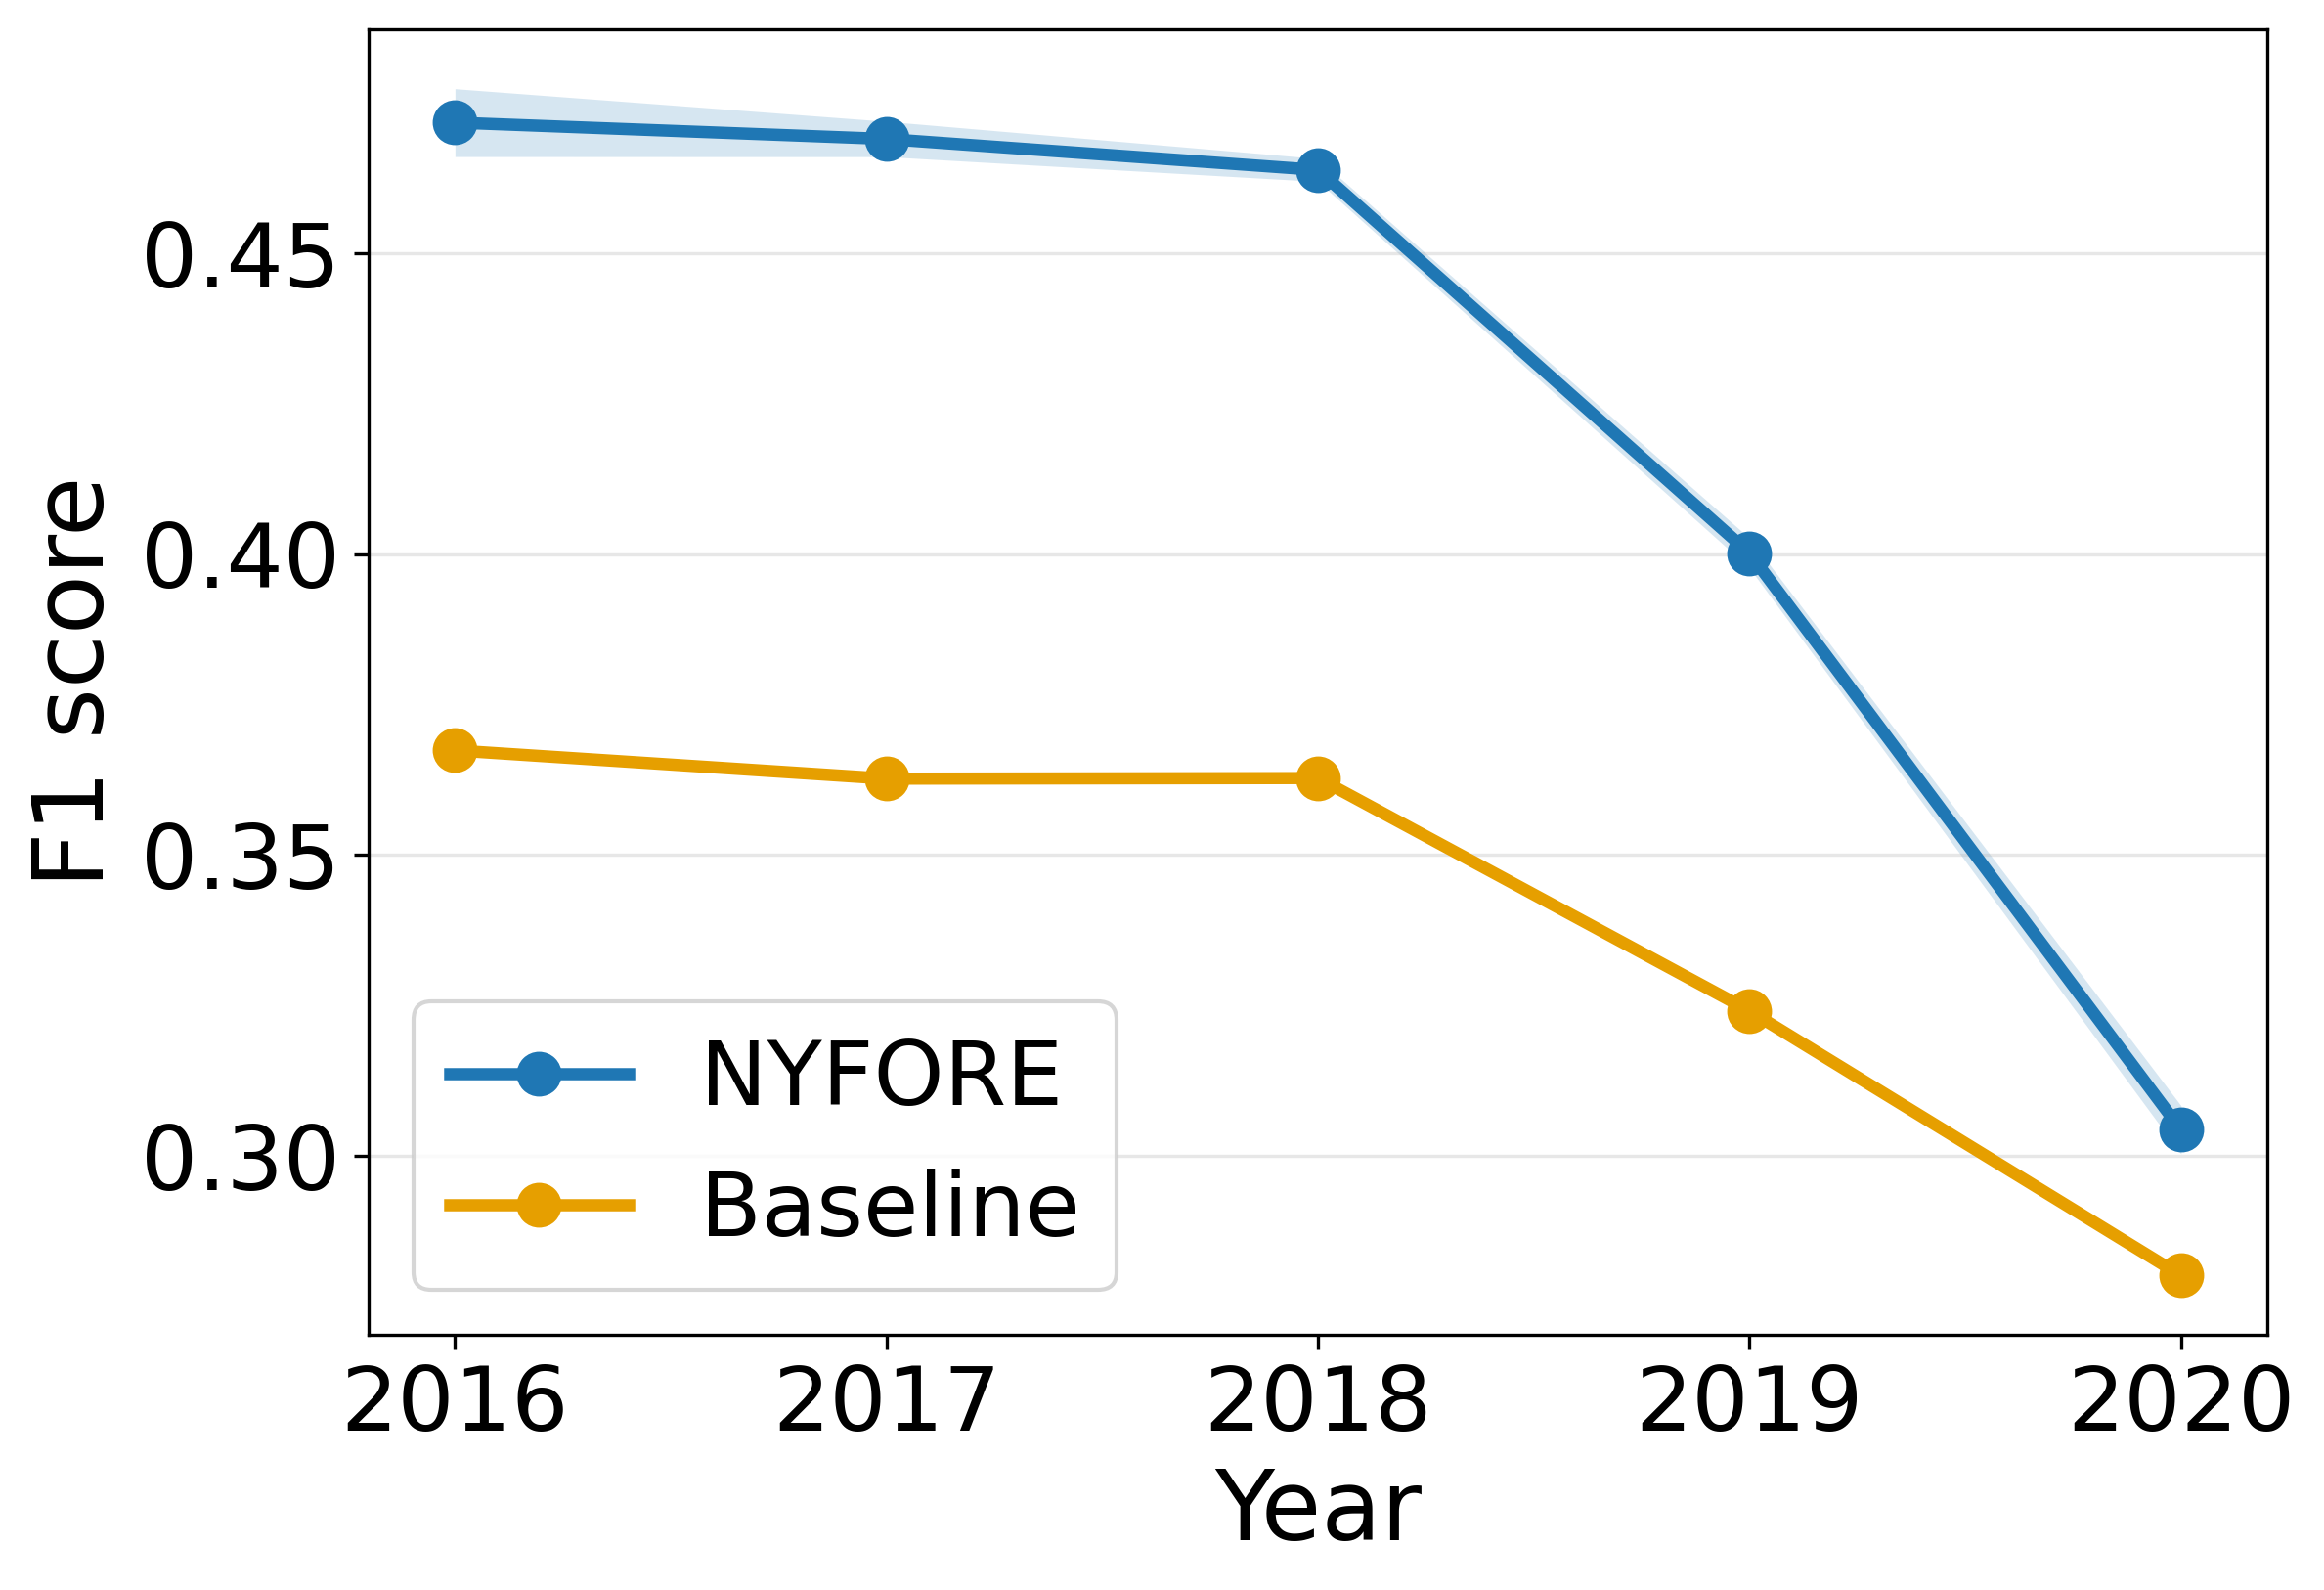

In [126]:
_plot_with_std(_metrics, run_names, 'Test', 'val_f1')